In [3]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [4]:
# 加载数据集（使用Iris数据集作为例子）
iris = pd.read_csv('data\iris.csv')  #读取数据文件
X = iris.iloc[:, :4].values  #获得样本数据
y = iris.iloc[:,-1].values   #获得样本的类标签

# 1. 获得PCA降维到2维后的数据,保存在data_pca中
# 补充你的代码
pca = PCA(n_components=2, random_state=42)
data_pca = pca.fit_transform(X)


print('PCA降维:\n',data_pca)

PCA降维:
 [[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]
 [-2.28085963  0.74133045]
 [-2.82053775 -0.08946138]
 [-2.62614497  0.16338496]
 [-2.88638273 -0.57831175]
 [-2.6727558  -0.11377425]
 [-2.50694709  0.6450689 ]
 [-2.61275523  0.01472994]
 [-2.78610927 -0.235112  ]
 [-3.22380374 -0.51139459]
 [-2.64475039  1.17876464]
 [-2.38603903  1.33806233]
 [-2.62352788  0.81067951]
 [-2.64829671  0.31184914]
 [-2.19982032  0.87283904]
 [-2.5879864   0.51356031]
 [-2.31025622  0.39134594]
 [-2.54370523  0.43299606]
 [-3.21593942  0.13346807]
 [-2.30273318  0.09870885]
 [-2.35575405 -0.03728186]
 [-2.50666891 -0.14601688]
 [-2.46882007  0.13095149]
 [-2.56231991  0.36771886]
 [-2.63953472  0.31203998]
 [-2.63198939 -0.19696122]
 [-2.58739848 -0.20431849]
 [-2.4099325   0.41092426]
 [-2.64886233  0.81336382]
 [-2.59873675  1.09314576]
 [-2.63692688 -0.12132235]
 [-2.86624165  0.06936447]
 [-2.62523805  0.599

In [5]:

# KNN算法类定义
class KNN:
    def __init__(self, k=3):
        self.k = k  # 设置邻居数目    

    # 存储训练数据
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    #2. 计算欧氏距离
    def euclidean_distance(self, point1, point2):
        #补充你的代码
        return np.linalg.norm(point1 - point2)
    #3. 预测一组数据点的类别
    def predict(self, X_test):
        predictions = []
        for point in X_test:
            distances = [self.euclidean_distance(point, x_train) for x_train in self.X_train]
            neighbor_idxs = np.argsort(distances)[:self.k]
            neighbor_labels = self.y_train[neighbor_idxs]
            most_common = Counter(neighbor_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)

In [6]:
# 数据集划分，80%训练集，20%测试集
X_train, X_test, y_train, y_test = train_test_split(data_pca, y, test_size=0.2, random_state=42)

# 初始化KNN模型并训练
knn = KNN(k=3)
knn.fit(X_train, y_train)

# 对测试集进行预测
y_pred = knn.predict(X_test)

# 打印预测结果
print("预测结果：", y_pred)
print("真实标签：", y_test)


预测结果： ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']
真实标签： ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']


In [11]:
from sklearn.metrics import accuracy_score, classification_report

# 评估分类器的性能
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=np.unique(y)))

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
# 4. 参与测试的数据中，每类各有几个？
from collections import defaultdict

class_counts = Counter(y_test)
print("测试集各类数量:")
for label, count in class_counts.items():
    print(f"{label}: {count}")

# 5. 针对上述预测结果，具体解释三类测试数据中各有几个被预测错了，被错误预测为哪类？
errors = defaultdict(list)
for true_label, pred_label in zip(y_test, y_pred):
    if true_label != pred_label:
        errors[true_label].append(pred_label)

print("\n各类预测错误情况:")
for label in ["setosa", "versicolor", "virginica"]:
    wrong_preds = errors.get(label, [])
    if wrong_preds:
        counts = Counter(wrong_preds)
        details = ", ".join([f"被预测为{pred}:{cnt}个" for pred, cnt in counts.items()])
        print(f"{label}: 共{len(wrong_preds)}个错误 -> {details}")
    else:
        print(f"{label}: 全部预测正确")

# 6. 分别给出versicolor类的recall,virginica类的precision的计算公式
recall_formula = "Recall_versicolor = TP_versicolor / (TP_versicolor + FN_versicolor)"
precision_formula = "Precision_virginica = TP_virginica / (TP_virginica + FP_virginica)"
print("\nversicolor类的Recall公式:")
print(recall_formula)
print("virginica类的Precision公式:")
print(precision_formula)

测试集各类数量:
versicolor: 9
setosa: 10
virginica: 11

各类预测错误情况:
setosa: 全部预测正确
versicolor: 全部预测正确
virginica: 全部预测正确

versicolor类的Recall公式:
Recall_versicolor = TP_versicolor / (TP_versicolor + FN_versicolor)
virginica类的Precision公式:
Precision_virginica = TP_virginica / (TP_virginica + FP_virginica)


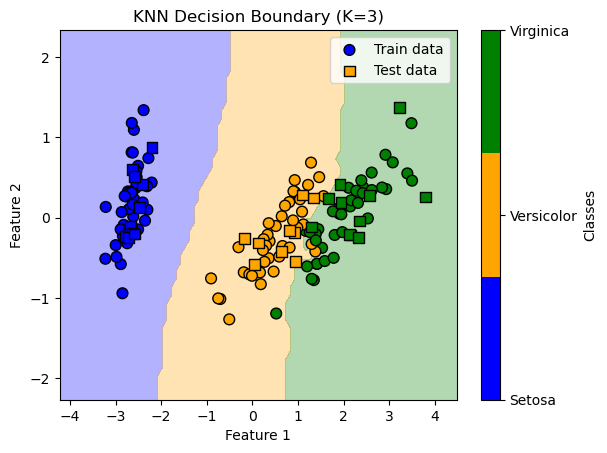

In [13]:

# 可视化

# 创建网格用于绘制决策边界
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

label_map = {'setosa': 0, 'versicolor': 1, 'virginica': 2}

# 批量预测网格上的类别
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid_points)
Z_mapped = np.vectorize(label_map.get)(Z)  # 映射为数字标签

# 将 Z 数组重塑为网格形状
Z_mapped = Z_mapped.reshape(xx.shape)

# 使用 label_map 将 y_train 和 y_test 映射为数字
y_train_mapped = np.vectorize(label_map.get)(y_train)
y_test_mapped = np.vectorize(label_map.get)(y_test)

# 自定义颜色映射，只使用3种颜色，直接使用颜色名称
colors = ['blue', 'orange', 'green']  # Setosa, Versicolor, Virginica
cmap = mcolors.ListedColormap(colors)

# 绘制决策边界
plt.contourf(xx, yy, Z_mapped, alpha=0.3, cmap=cmap, levels=np.arange(-0.5, 3.5, 1))

# 绘制训练数据点
scatter_train = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train_mapped, marker='o', edgecolor='k', s=60, cmap=cmap, label='Train data')

# 绘制测试数据点
scatter_test = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test_mapped, marker='s', edgecolor='k', s=60, cmap=cmap, label='Test data')

# 设置坐标轴标签和标题
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KNN Decision Boundary (K=3)')

# 自动生成图例
plt.legend()

# 获取 colorbar
cbar = plt.colorbar(scatter_train, label='Classes')

# 设置色条的刻度为三个类别，分别为 0, 1, 2（对应 Setosa, Versicolor, Virginica）
cbar.set_ticks([0, 1, 2])  # 设置为三个类别的刻度
cbar.set_ticklabels(['Setosa', 'Versicolor', 'Virginica'])  # 设置对应的标签

# 显示图形
plt.show()
